<a href="https://colab.research.google.com/github/MiguelAtencio/deep-learning-copilot/blob/main/ML4BI_E4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for BI 2

## (MORE) Deep Learning exercises for week 3

Load the newswire dataset from the exercises and prepare it to a neural network with two hidden layers.

Write a function that allows you to control whether a dropout is applied to each layer.

Finally, use the function to compare the validation lose curves for three different training runs: (1) dropout only in the first layer, (2) dropout only in the second layer, (3) dropout in the both layers, and (4) no dropout. Let the number of neurons in each run be the same, but think about what a reasonable number of neurons would be and why.

**Load and prepare the newswire dataset**

To have a much better result, I would have to overfit to the data first. Otherwise, the experiment would not be as clear as it could

In [2]:
from tensorflow.keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [4]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

**Create the function**

In [6]:
#YOUR CODE HERE
from tensorflow import keras
from tensorflow.keras import layers

def build_model(layer_sizes, dropout_rates, input_dim, output_size, output_activation="softmax"):
    """
    layer_sizes:   list of units per hidden layer, e.g. [256, 128, 64]
    dropout_rates: list of dropout rates per hidden layer (0 = no dropout)
                   must be the same length as layer_sizes
    input_dim:     dimensionality of the input layer
    output_size:   number of classes in the output layer
    output_activation: activation function for the output layer
    """
    inputs = keras.Input(shape=(input_dim,))
    x = inputs

    for units, rate in zip(layer_sizes, dropout_rates):
        x = keras.layers.Dense(units, activation='relu')(x)
        if rate > 0:
            x = keras.layers.Dropout(rate)(x)  # only added if rate is nonzero

    outputs = keras.layers.Dense(output_size, activation=output_activation)(x)
    return keras.Model(inputs, outputs)

In [7]:
def get_model(layer_sizes, dropout_rates, input_dim, output_size, output_activation="softmax"):
    model = build_model(layer_sizes=layer_sizes, dropout_rates=dropout_rates, input_dim=input_dim, output_size=output_size, output_activation=output_activation)

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

**Running the models**

In [12]:
x_train.shape, y_train.shape

((8982, 10000), (8982, 46))

In [29]:
configs = {
    "first": {"dropout_rates": [0.2, 0]},
    "second": {"dropout_rates": [0, 0.2]},
    "both": {"dropout_rates": [0.2, 0.2]},
    "none": {"dropout_rates": [0, 0]}
}

all_histories = {}

for name, config in configs.items():

    print(f"Training model with config: {name}")
    model = get_model(layer_sizes=[1024, 1024], dropout_rates=config["dropout_rates"], input_dim=x_train.shape[1], output_size=46)

    history = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.2, verbose=0)
    
    all_histories[name] = history

Training model with config: first
Training model with config: second
Training model with config: both
Training model with config: none


**Plot**

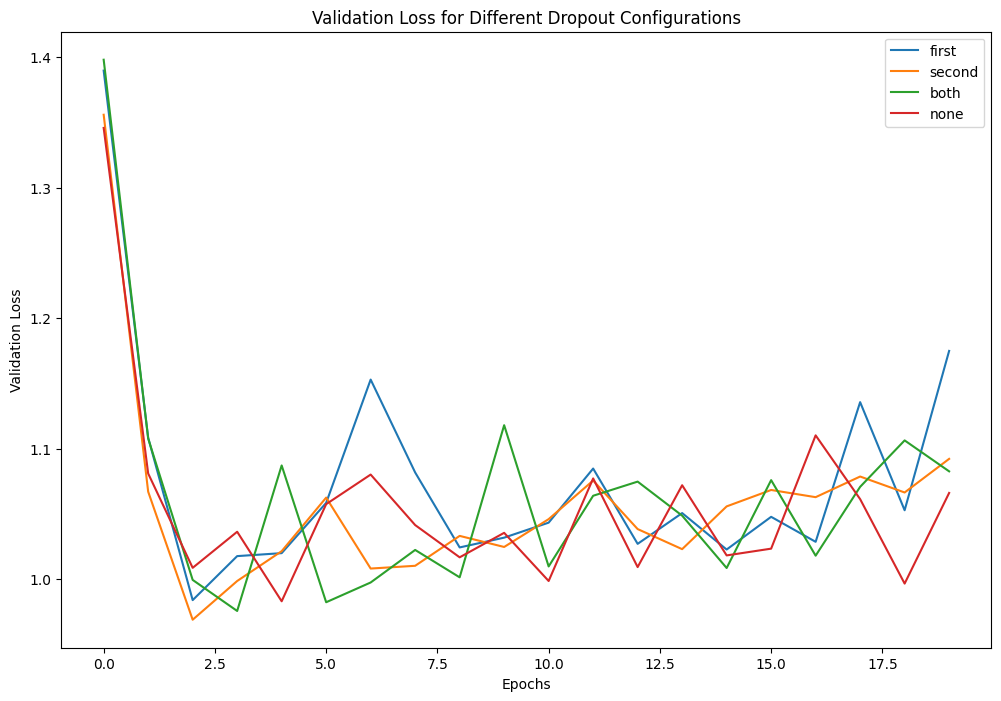

In [30]:
#YOUR CODE HERE
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for name, history in all_histories.items():
    plt.plot(history.history['val_loss'], label=name)

plt.title('Validation Loss for Different Dropout Configurations')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()  